In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

from prophet import Prophet

/home/sebnm/.cache/pypoetry/virtualenvs/forecasting-XEN0x0Nn-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
url1 = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df1 = pd.read_csv(url1)
df1.rename(columns={"date":"ds", "OT": "y"}, inplace = True)
df1['ds'] = pd.to_datetime(df1['ds'])

In [3]:
n_test = 24
train  = df1.iloc[:-n_test,:][["ds","y"]]
test   = df1.iloc[-n_test:,:][["ds","y"]]

In [4]:
m = Prophet()
m.fit(train)

11:54:41 - cmdstanpy - INFO - Chain [1] start processing
11:54:44 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
forecast = m.predict(test)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2018-06-25 20:00:00,11.966781,8.144030,15.683441
1,2018-06-25 21:00:00,11.742708,7.939609,15.669121
2,2018-06-25 22:00:00,11.565821,7.941968,15.698264
3,2018-06-25 23:00:00,11.407855,7.438607,15.259577
4,2018-06-26 00:00:00,11.269998,7.646891,15.289514
5,2018-06-26 01:00:00,11.158516,7.254773,15.086493
6,2018-06-26 02:00:00,11.057295,7.073930,14.886797
7,2018-06-26 03:00:00,10.936699,7.062921,14.709867
8,2018-06-26 04:00:00,10.792517,7.226948,14.535090
9,2018-06-26 05:00:00,10.669732,6.859213,14.206834


In [6]:
bias = round((forecast["yhat"].to_numpy() - test["y"].to_numpy()).mean(),3)
print(bias)

1.889


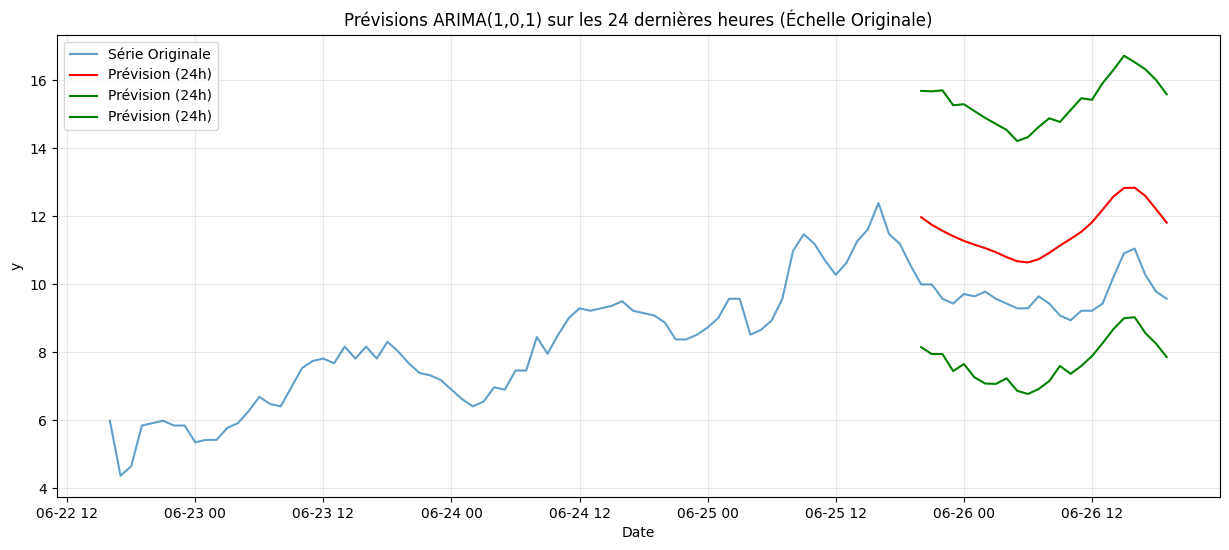

--- Performances sur 24h ---
MAE	: 1.8889
RMSE	: 1.9446
MAPE	: 19.57%


In [7]:
# ********** PLOT ***********
plt.figure(figsize=(15, 6))

plt.plot(df1["ds"][-100:], df1["y"][-100:].values, label='Série Originale', color='tab:blue', alpha=0.7)
plt.plot(test["ds"].values, forecast["yhat"].values, label=f'Prévision ({n_test}h)', color='red', linewidth=1.5)
plt.plot(test["ds"].values, forecast["yhat_lower"].values, label=f'Prévision ({n_test}h)', color='green', linewidth=1.5)
plt.plot(test["ds"].values, forecast["yhat_upper"].values, label=f'Prévision ({n_test}h)', color='green', linewidth=1.5)


plt.title(f"Prévisions ARIMA(1,0,1) sur les {n_test} dernières heures (Échelle Originale)")
plt.xlabel("Date")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rmse = np.sqrt(mean_squared_error(test["y"].values, forecast["yhat"].values))
mape = np.mean(np.abs((test["y"].values - forecast["yhat"].values) / test["y"].values)) * 100
mae  = mean_absolute_error(test["y"].values, forecast["yhat"].values)

print(f"--- Performances sur {n_test}h ---")
print(f"MAE\t: {mae:.4f}")
print(f"RMSE\t: {rmse:.4f}")
print(f"MAPE\t: {mape:.2f}%")

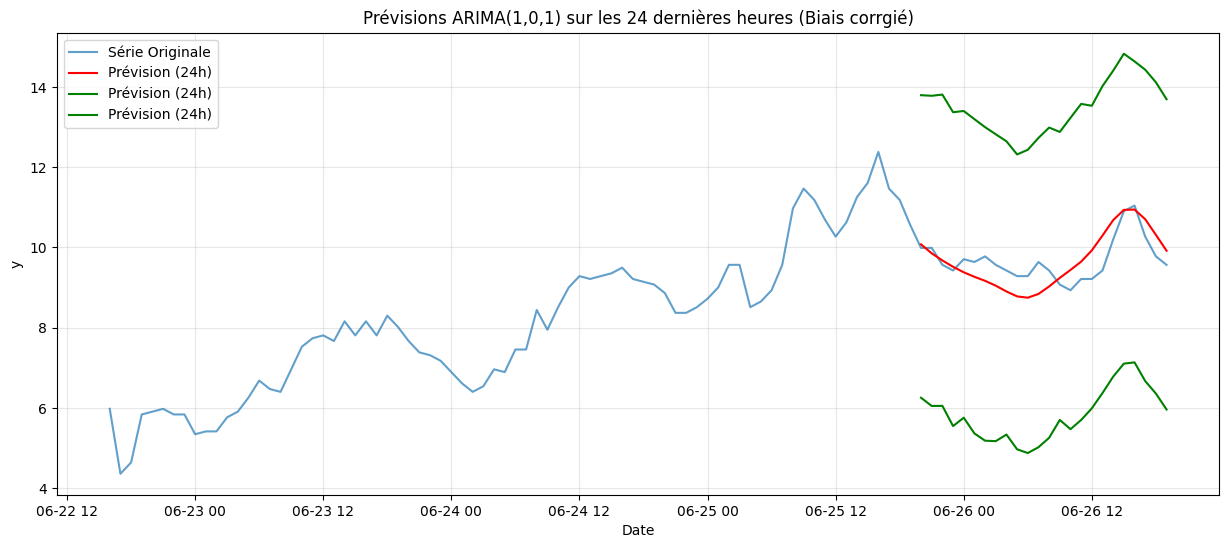

--- Performances sur 24h avec le biais corrigé ---
MAE	: 0.4014
RMSE	: 0.4620
MAPE	: 4.21%


In [9]:
# ********** PLOT ***********
plt.figure(figsize=(15, 6))

plt.plot(df1["ds"][-100:], df1["y"][-100:].values, label='Série Originale', color='tab:blue', alpha=0.7)
plt.plot(test["ds"].values, forecast["yhat"].values - bias, label=f'Prévision ({n_test}h)', color='red', linewidth=1.5)
plt.plot(test["ds"].values, forecast["yhat_lower"].values - bias, label=f'Prévision ({n_test}h)', color='green', linewidth=1.5)
plt.plot(test["ds"].values, forecast["yhat_upper"].values - bias, label=f'Prévision ({n_test}h)', color='green', linewidth=1.5)


plt.title(f"Prévisions ARIMA(1,0,1) sur les {n_test} dernières heures (Biais corrgié)")
plt.xlabel("Date")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rmse = np.sqrt(mean_squared_error(test["y"].values, forecast["yhat"].values - bias))
mape = np.mean(np.abs((test["y"].values - (forecast["yhat"].values - bias)) / test["y"].values)) * 100
mae  = mean_absolute_error(test["y"].values, forecast["yhat"].values - bias)

print(f"--- Performances sur {n_test}h avec le biais corrigé ---")
print(f"MAE\t: {mae:.4f}")
print(f"RMSE\t: {rmse:.4f}")
print(f"MAPE\t: {mape:.2f}%")